# Song Recommendation System using Audio Features
This project builds a content-based music recommendation system based on audio features such as danceability, energy, loudness and tempo.
The goal is to recommend songs that are similar in musical characteristics to a given input track.

## Project Goals
- Explore the distribution of audio features
- Analyse relationships between musical attributes
- Build a content-based recommender system
- Recommend similar songs based on audio features

## Dataset
The dataset contains audio features for a large number of songs.  
Each track includes musical attributes extracted from audio analysis.

Key variables include:

- danceability: how suitable a track is for dancing
- energy: intensity and activity of the track
- loudness: overall loudness in decibels
- valence: musical positiveness
- tempo: beats per minute

### Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

### Load Dataset

In [2]:
df = pd.read_csv("../data/tracks_features.csv")

print(df.shape)
print(df.columns)
df.head()

(1204025, 24)
Index(['id', 'name', 'album', 'album_id', 'artists', 'artist_ids',
       'track_number', 'disc_number', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
       'time_signature', 'year', 'release_date'],
      dtype='object')


,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],1,1,False,0.470,...,0.0727,0.02610,0.000011,0.3560,0.503,117.906,210133,4.0,1999,1999-11-02
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],2,1,True,0.599,...,0.1880,0.01290,0.000071,0.1550,0.489,103.680,206200,4.0,1999,1999-11-02
2,1hR0fIFK2qRG3f3RF70pb7,Calm Like a Bomb,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],3,1,False,0.315,...,0.4830,0.02340,0.000002,0.1220,0.370,149.749,298893,4.0,1999,1999-11-02
3,2lbASgTSoDO7MTuLAXlTW0,Mic Check,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],4,1,True,0.440,...,0.2370,0.16300,0.000004,0.1210,0.574,96.752,213640,4.0,1999,1999-11-02
4,1MQTmpYOZ6fcMQc56Hdo7T,Sleep Now In the Fire,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],5,1,False,0.426,...,0.0701,0.00162,0.105000,0.0789,0.539,127.059,205600,4.0,1999,1999-11-02


In [3]:
df.info()
print(df.isna().sum())
print("Duplikate gesamt:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1204025 entries, 0 to 1204024
Data columns (total 24 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1204025 non-null  object 
 1   name              1204022 non-null  object 
 2   album             1204014 non-null  object 
 3   album_id          1204025 non-null  object 
 4   artists           1204025 non-null  object 
 5   artist_ids        1204025 non-null  object 
 6   track_number      1204025 non-null  int64  
 7   disc_number       1204025 non-null  int64  
 8   explicit          1204025 non-null  bool   
 9   danceability      1204025 non-null  float64
 10  energy            1204025 non-null  float64
 11  key               1204025 non-null  int64  
 12  loudness          1204025 non-null  float64
 13  mode              1204025 non-null  int64  
 14  speechiness       1204025 non-null  float64
 15  acousticness      1204025 non-null  float64
 16  

## Data Preprocessing

To prepare the dataset for the recommendation model, relevant audio features are selected

In [4]:
selected_columns = [
    "name",
    "artists",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "year"
]

df_model = df[selected_columns].copy()
df_model["song_label"] = df_model["name"].astype(str).str.strip() + " - " + df_model["artists"].astype(str).str.strip()
df_model.head()

,name,artists,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,year,song_label
0,Testify,['Rage Against The Machine'],0.470,0.978,-5.399,0.0727,0.02610,0.000011,0.3560,0.503,117.906,1999,Testify - ['Rage Against The Machine']
1,Guerrilla Radio,['Rage Against The Machine'],0.599,0.957,-5.764,0.1880,0.01290,0.000071,0.1550,0.489,103.680,1999,Guerrilla Radio - ['Rage Against The Machine']
2,Calm Like a Bomb,['Rage Against The Machine'],0.315,0.970,-5.424,0.4830,0.02340,0.000002,0.1220,0.370,149.749,1999,Calm Like a Bomb - ['Rage Against The Machine']
3,Mic Check,['Rage Against The Machine'],0.440,0.967,-5.830,0.2370,0.16300,0.000004,0.1210,0.574,96.752,1999,Mic Check - ['Rage Against The Machine']
4,Sleep Now In the Fire,['Rage Against The Machine'],0.426,0.929,-6.729,0.0701,0.00162,0.105000,0.0789,0.539,127.059,1999,Sleep Now In the Fire - ['Rage Against The Mac...


## Feature Selection

The recommendation system is based on numerical audio features that describe musical characteristics.

The following features are used:

- danceability
- energy
- loudness
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo
- year

In [5]:
feature_cols = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "year"
]

X = df_model[feature_cols].copy().astype("float32")
X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,year
0,0.470,0.978,-5.399,0.0727,0.02610,0.000011,0.3560,0.503,117.905998,1999.0
1,0.599,0.957,-5.764,0.1880,0.01290,0.000071,0.1550,0.489,103.680000,1999.0
2,0.315,0.970,-5.424,0.4830,0.02340,0.000002,0.1220,0.370,149.748993,1999.0
3,0.440,0.967,-5.830,0.2370,0.16300,0.000004,0.1210,0.574,96.751999,1999.0
4,0.426,0.929,-6.729,0.0701,0.00162,0.105000,0.0789,0.539,127.058998,1999.0


# Explorative Datenanalyse

In [6]:
print(df_model.shape)
df_model.head()

(1204025, 13)


,name,artists,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,year,song_label
0,Testify,['Rage Against The Machine'],0.470,0.978,-5.399,0.0727,0.02610,0.000011,0.3560,0.503,117.906,1999,Testify - ['Rage Against The Machine']
1,Guerrilla Radio,['Rage Against The Machine'],0.599,0.957,-5.764,0.1880,0.01290,0.000071,0.1550,0.489,103.680,1999,Guerrilla Radio - ['Rage Against The Machine']
2,Calm Like a Bomb,['Rage Against The Machine'],0.315,0.970,-5.424,0.4830,0.02340,0.000002,0.1220,0.370,149.749,1999,Calm Like a Bomb - ['Rage Against The Machine']
3,Mic Check,['Rage Against The Machine'],0.440,0.967,-5.830,0.2370,0.16300,0.000004,0.1210,0.574,96.752,1999,Mic Check - ['Rage Against The Machine']
4,Sleep Now In the Fire,['Rage Against The Machine'],0.426,0.929,-6.729,0.0701,0.00162,0.105000,0.0789,0.539,127.059,1999,Sleep Now In the Fire - ['Rage Against The Mac...


In [7]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1204025 entries, 0 to 1204024
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   name              1204022 non-null  object 
 1   artists           1204025 non-null  object 
 2   danceability      1204025 non-null  float64
 3   energy            1204025 non-null  float64
 4   loudness          1204025 non-null  float64
 5   speechiness       1204025 non-null  float64
 6   acousticness      1204025 non-null  float64
 7   instrumentalness  1204025 non-null  float64
 8   liveness          1204025 non-null  float64
 9   valence           1204025 non-null  float64
 10  tempo             1204025 non-null  float64
 11  year              1204025 non-null  int64  
 12  song_label        1204025 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 119.4+ MB


In [8]:
df_model.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,year
count,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06
mean,4.930565e-01,5.095363e-01,-1.180870e+01,8.438219e-02,4.467511e-01,2.828605e-01,2.015994e-01,4.279866e-01,1.176344e+02,2.007328e+03
std,1.896694e-01,2.946839e-01,6.982132e+00,1.159914e-01,3.852014e-01,3.762844e-01,1.804591e-01,2.704846e-01,3.093705e+01,1.210117e+01
min,0.000000e+00,0.000000e+00,-6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.560000e-01,2.520000e-01,-1.525400e+01,3.510000e-02,3.760000e-02,7.600000e-06,9.680000e-02,1.910000e-01,9.405400e+01,2.002000e+03
50%,5.010000e-01,5.240000e-01,-9.791000e+00,4.460000e-02,3.890000e-01,8.080000e-03,1.250000e-01,4.030000e-01,1.167260e+02,2.009000e+03
75%,6.330000e-01,7.660000e-01,-6.717000e+00,7.230000e-02,8.610000e-01,7.190000e-01,2.450000e-01,6.440000e-01,1.370460e+02,2.015000e+03
max,1.000000e+00,1.000000e+00,7.234000e+00,9.690000e-01,9.960000e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.489340e+02,2.020000e+03


### Feature Distributions

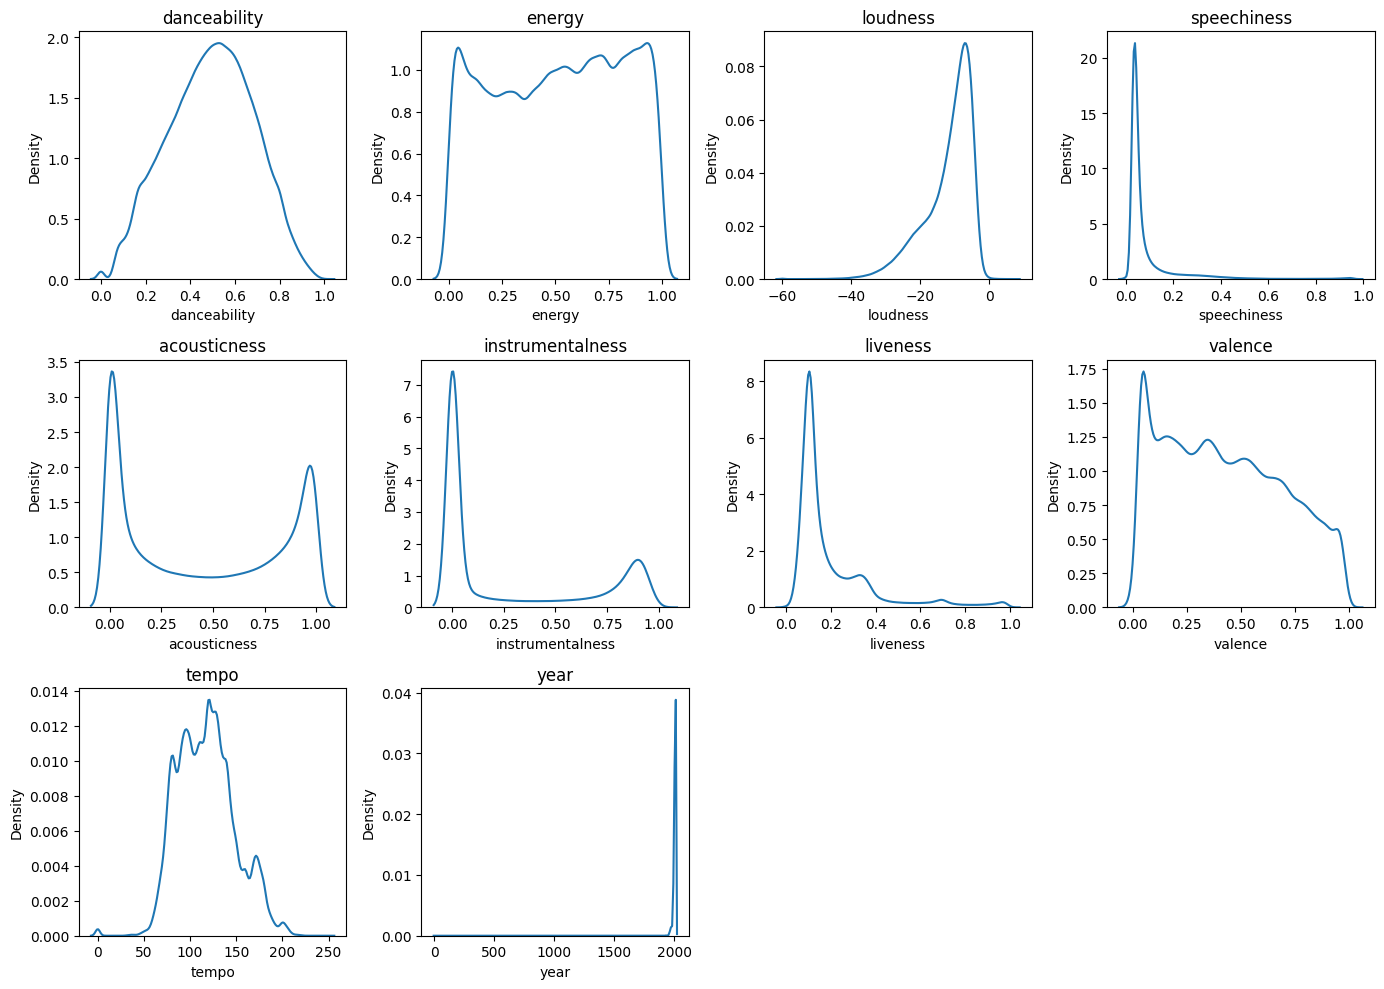

In [9]:
plt.figure(figsize=(14,10))

for i, col in enumerate(feature_cols):
    plt.subplot(3,4,i+1)
    sns.kdeplot(df_model[col], fill=False, bw_adjust=1.3)
    plt.title(col)

plt.tight_layout()
plt.show()

There are various distributions throughout the features. Acousticness and instrumentalness tend to be extremes. Tempo and danceability exhibit normal-distribution-type curves. Energy is consistent throughout the range, similar to a uniform distribution. The rest of the features tend to be skewed towards the left, with loudness and year being the exceptions in being skewed to the right. 

### Correlation Analysis

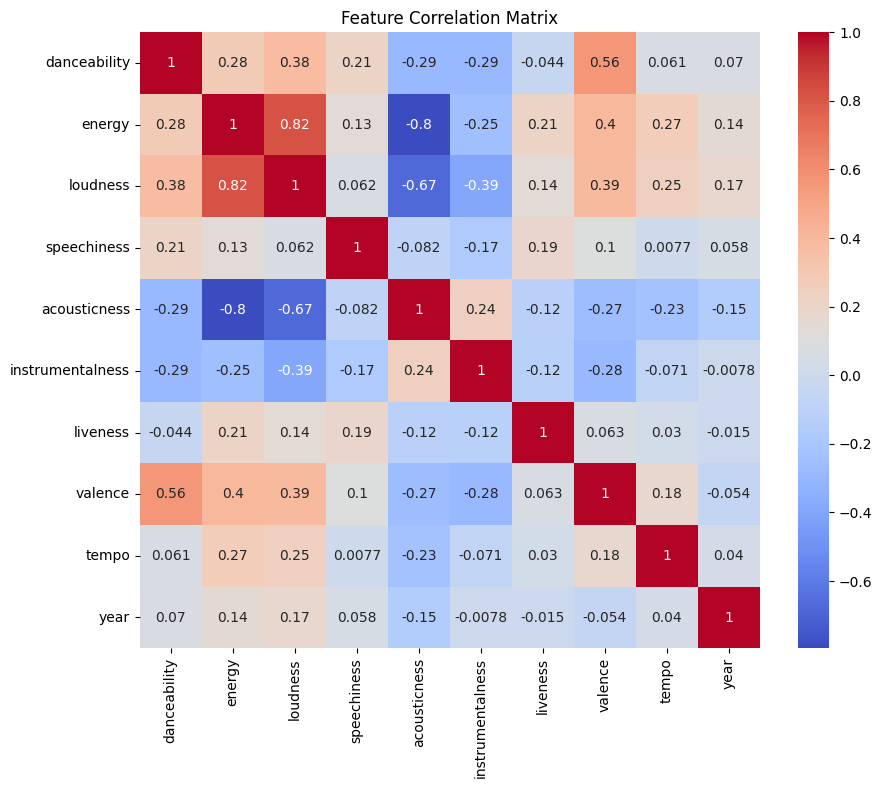

In [10]:
corr = df_model[feature_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

The correlation matrix most notably shows a positive correlation between loudness and energy, which is expected since louder tracks tend to have higher perceived energy. Furthermore, it depicts a negative correlation between energy, loudness and acousticness, which accentuates the difference of acoustic and electronic music styles.

### Feature Relationships

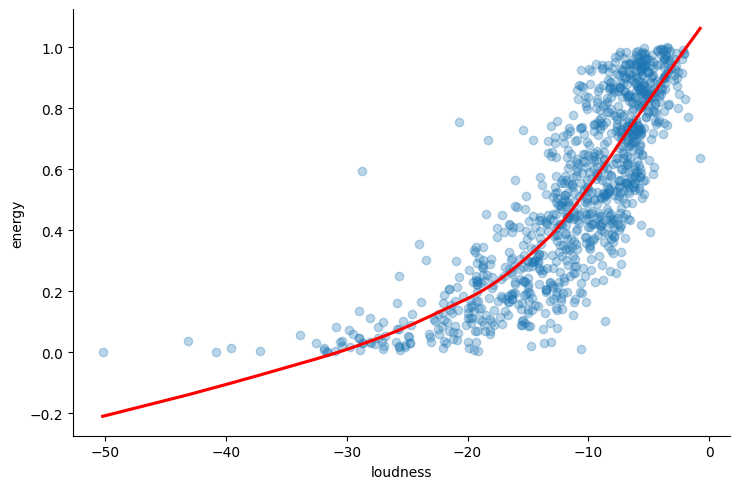

In [11]:
sns.lmplot(
    data=df_model.sample(1000),
    x="loudness",
    y="energy",
    scatter_kws={"alpha":0.3},
    line_kws={"color": "red"},
    lowess=True,
    height=5,
    aspect=1.5
)
plt.show()

The scatterplot exhibits a positive association between loudness and energy of the songs. That is expected due to the nature of louder music being perceived as more energetic. 

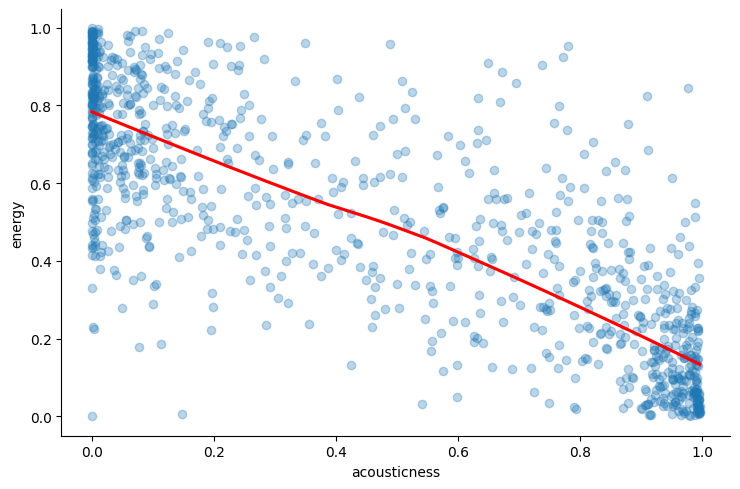

In [12]:
sns.lmplot(
    data=df_model.sample(1000),
    x="acousticness",
    y="energy",
    scatter_kws={"alpha":0.3},
    line_kws={"color": "red"},
    lowess=True,
    height=5,
    aspect=1.5
)
plt.show()

The scatterplot exhibits a negative association between acousticness and energy of the songs. That is expected because electronic music (closer to 0 on the acousticness scale) tends to be more energetic than acoustic music.

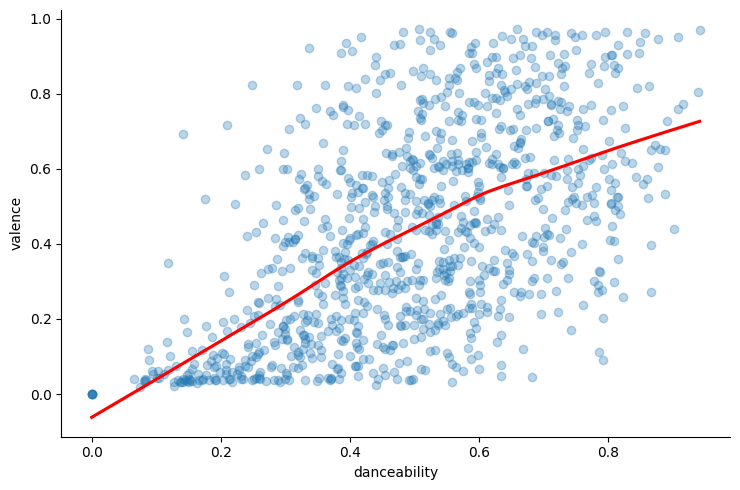

In [13]:
sns.lmplot(
    data=df_model.sample(1000),
    x="danceability",
    y="valence",
    scatter_kws={"alpha":0.3},
    line_kws={"color": "red"},
    lowess=True,
    height=5,
    aspect=1.5
)
plt.show()

The scatterplot exhibits a positive association between danceability and valence of the songs. That is expected because the danceability benefits from the song being more positively connotated in an emotional way.

## Feature Scaling

Because the features have different scales (e.g. tempo vs danceability), the data is standardized and normalized before training the recommendation model.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype("float32")

X_normalized = normalize(X_scaled, norm="l2")

## Recommendation Model

A content-based recommender system is implemented using a Nearest Neighbors model with euclidean distance.

Songs are represented as vectors in a multi-dimensional feature space.  
The model identifies songs with the smallest euclidean distance to a given track.

In [15]:
nn_model = NearestNeighbors(
    n_neighbors=6,
    algorithm="brute",
    metric="euclidean"
)

nn_model.fit(X_normalized)

NearestNeighbors(algorithm='brute', metric='euclidean', n_neighbors=6)

In [16]:
df_model = df_model.reset_index(drop=True)

song_to_index = pd.Series(df_model.index, index=df_model["song_label"]).drop_duplicates()
song_to_index.head()

song_label
Testify - ['Rage Against The Machine']                  0
Guerrilla Radio - ['Rage Against The Machine']          1
Calm Like a Bomb - ['Rage Against The Machine']         2
Mic Check - ['Rage Against The Machine']                3
Sleep Now In the Fire - ['Rage Against The Machine']    4
dtype: int64

## Recommendation Function

In [17]:
def recommend_songs(song_label, n=5, year_range=None):

    if song_label not in song_to_index.index:
        return f"Song '{song_label}' not found."
    
    idx = song_to_index[song_label]
    
    song_vector = X_normalized[idx].reshape(1, -1)
    distances, indices = nn_model.kneighbors(song_vector, n_neighbors=50)

    recommended_indices = indices.flatten()[1:]
    recommended_distances = distances.flatten()[1:]

    result = df_model.loc[recommended_indices, ["song_label", "year"]].copy()
    result["euclidean_distance"] = recommended_distances

    if year_range is not None:
        min_year, max_year = year_range
        result = result[
            (result["year"] >= min_year) &
            (result["year"] <= max_year)
        ]

    return result.head(n)

## Song Search Function

In [18]:
def search_song(query, n=20):
    query = str(query).strip()
    
    matches = df_model[
        df_model["song_label"].str.contains(query, case=False, na=False)
    ][["name", "artists", "song_label", "year"]].head(n)
    
    if matches.empty:
        return f"No songs found for '{query}'."
    
    return matches

## Example Recommendations

In [19]:
search_song("All Along The Watchtower")

,name,artists,song_label,year
8713,All Along The Watchtower,"[""Pickin' On Series""]","All Along The Watchtower - [""Pickin' On Series""]",1999
10604,All Along the Watchtower - Live at Central Par...,['Dave Matthews Band'],All Along the Watchtower - Live at Central Par...,2003
11213,All Along The Watchtower - Live - 1991,['Indigo Girls'],All Along The Watchtower - Live - 1991 - ['Ind...,1991
50962,"All Along the Watchtower - Live at Trax, Charl...",['Dave Matthews Band'],"All Along the Watchtower - Live at Trax, Charl...",1994
84238,All Along The Watchtower,['Vitamin String Quartet'],All Along The Watchtower - ['Vitamin String Qu...,2003
93406,All Along the Watchtower,['Pat Flynn'],All Along the Watchtower - ['Pat Flynn'],2007
108036,All Along The Watchtower,['Tom Landa & The Paperboys'],All Along The Watchtower - ['Tom Landa & The P...,1993
132548,All Along the Watchtower - Live at Madison Squ...,['Neil Young'],All Along the Watchtower - Live at Madison Squ...,1993
143590,All Along the Watchtower,['Bob Dylan'],All Along the Watchtower - ['Bob Dylan'],1967
205772,All Along the Watchtower,"['Eddie Vedder', 'The Million Dollar Bashers']","All Along the Watchtower - ['Eddie Vedder', 'T...",2007


In [20]:
recommend_songs("All Along The Watchtower - Live - 1991 - ['Indigo Girls']")

,song_label,year,euclidean_distance
107861,"Night and Day - ['Morgy Craig', 'Steve Barnes'...",1999,0.162145
243869,Chanson pour Léolo - ['Ginette Reno'],1993,0.169182
1012839,Introduction to Higher Ground by Rev. Jaspar W...,1987,0.174171
566061,Shed a Little Light - ['James Taylor'],1993,0.181018
228577,Can You Read My Mind - ['Barbara Cook'],1994,0.184260


In [21]:
recommend_songs("All Along The Watchtower - Live - 1991 - ['Indigo Girls']", year_range=(1985, 1995))

,song_label,year,euclidean_distance
243869,Chanson pour Léolo - ['Ginette Reno'],1993,0.169182
1012839,Introduction to Higher Ground by Rev. Jaspar W...,1987,0.174171
566061,Shed a Little Light - ['James Taylor'],1993,0.181018
228577,Can You Read My Mind - ['Barbara Cook'],1994,0.184260
1059119,You're Gonna Make Me Lonesome When You Go - Li...,1994,0.185530


In [22]:
search_song("90210")

,name,artists,song_label,year
7463,90210,['Smiley'],90210 - ['Smiley'],2020
49994,Stillorgan 90210,['Dustin'],Stillorgan 90210 - ['Dustin'],2005
419489,90210 (feat. G-Eazy),"['blackbear', 'G-Eazy']","90210 (feat. G-Eazy) - ['blackbear', 'G-Eazy']",2015
997456,Transylvania 90210,['Wednesday 13'],Transylvania 90210 - ['Wednesday 13'],2014
1103206,90210,['Giant Drag'],90210 - ['Giant Drag'],2013
1123636,90210 (feat. Kacy Hill),"['Travis Scott', 'Kacy Hill']","90210 (feat. Kacy Hill) - ['Travis Scott', 'Ka...",2015


In [23]:
recommend_songs("90210 (feat. Kacy Hill) - ['Travis Scott', 'Kacy Hill']")

,song_label,year,euclidean_distance
533318,Stock Photo Girl - ['Nerf Herder'],2016,0.195654
807965,"Monolith - ['Josh Klinghoffer', 'Chad Smith']",2019,0.198838
668915,Girl Next Door - ['Luke Child'],2017,0.203616
1126495,No Love - ['Tommy Lee Sparta'],2013,0.204089
1162838,Nowhere - ['Chris Brown'],2017,0.212281


The recommended tracks exhibit similar values in energy, danceability and tempo, indicating that the model captures musical similarity in terms of audio features.

In [24]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_normalized)

df_model["PC1"] = X_pca[:,0]
df_model["PC2"] = X_pca[:,1]

In [25]:
pca = PCA(n_components=2)
pca.fit(X_normalized)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2"],
    index=feature_cols
)

print(loadings)

                       PC1       PC2
danceability      0.292760  0.535032
energy            0.501932 -0.291514
loudness          0.440008 -0.101830
speechiness       0.074300  0.002180
acousticness     -0.489926  0.359018
instrumentalness -0.268505 -0.387091
liveness          0.071432 -0.148862
valence           0.336497  0.493504
tempo             0.160005 -0.232544
year              0.084679 -0.140960


In [26]:
plt.style.use("seaborn-v0_8")
def pca_recommended_songs(song_label, year_ranged=None):
    rec = recommend_songs(song_label, year_range=year_ranged)

    rec_indices = rec.index

    plt.figure(figsize=(12,7))

    sample = df_model.sample(100000, random_state=42)

    # all songs
    sns.kdeplot(
        data=sample,
        x="PC1",
        y="PC2",
        fill=True,
        cmap="Blues",
        alpha=0.5,
        levels=10,
        thresh=0.05
    )

    sns.kdeplot(
        data=sample,
        x="PC1",
        y="PC2",
        color="black",
        levels=1,
        linewidths=0.5,
        thresh=0.05
    )

    # recommended songs
    plt.scatter(
        df_model.loc[rec_indices,"PC1"],
        df_model.loc[rec_indices,"PC2"],
        color="red",
        s=100,
        label="Recommendations"
    )

    plt.legend()
    plt.title("Recommended Songs in PCA Space")

    # input song
    song_idx = song_to_index[song_label]

    plt.scatter(
        df_model.loc[song_idx,"PC1"],
        df_model.loc[song_idx,"PC2"],
        color="black",
        s=150,
        label="Input Song"
    )

    plt.legend()
    # plt.savefig("pca_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

    return rec

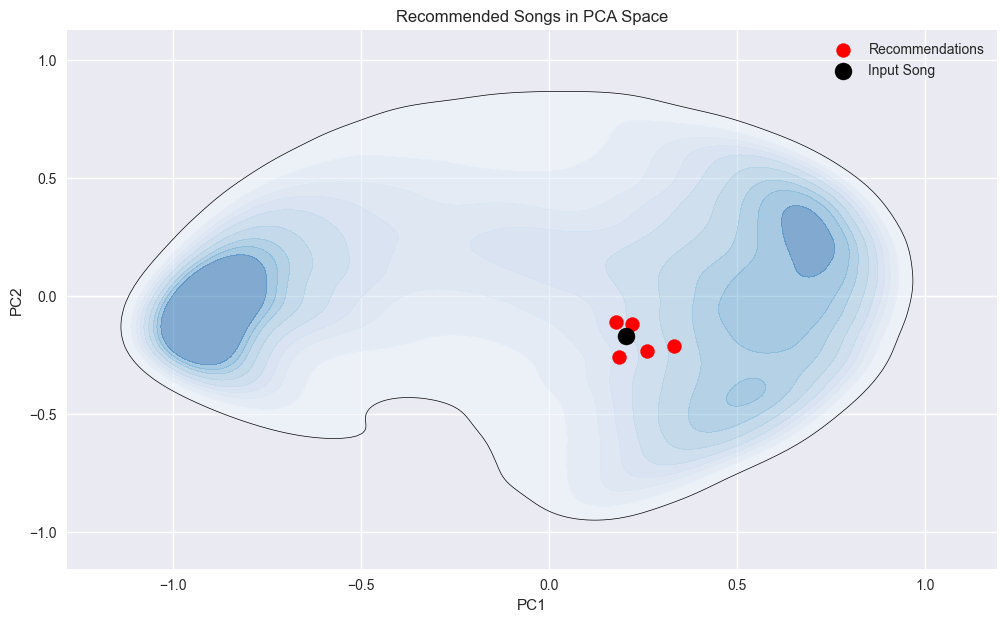

,song_label,year,euclidean_distance
533318,Stock Photo Girl - ['Nerf Herder'],2016,0.195654
807965,"Monolith - ['Josh Klinghoffer', 'Chad Smith']",2019,0.198838
668915,Girl Next Door - ['Luke Child'],2017,0.203616
1126495,No Love - ['Tommy Lee Sparta'],2013,0.204089
1162838,Nowhere - ['Chris Brown'],2017,0.212281


In [27]:
pca_recommended_songs("90210 (feat. Kacy Hill) - ['Travis Scott', 'Kacy Hill']")

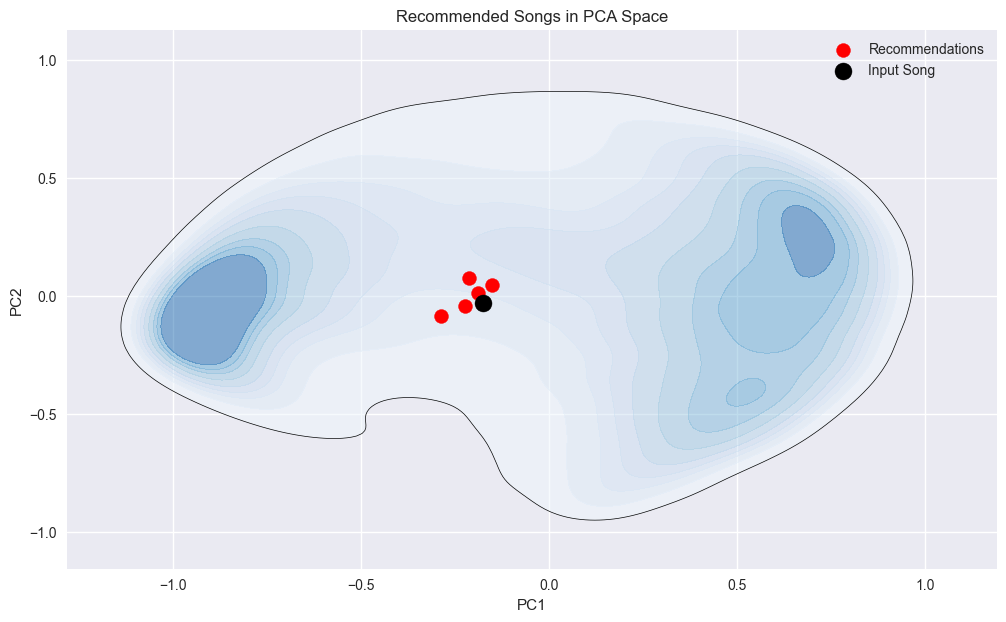

,song_label,year,euclidean_distance
243869,Chanson pour Léolo - ['Ginette Reno'],1993,0.169182
1012839,Introduction to Higher Ground by Rev. Jaspar W...,1987,0.174171
566061,Shed a Little Light - ['James Taylor'],1993,0.181018
228577,Can You Read My Mind - ['Barbara Cook'],1994,0.184260
1059119,You're Gonna Make Me Lonesome When You Go - Li...,1994,0.185530


In [28]:
pca_recommended_songs("All Along The Watchtower - Live - 1991 - ['Indigo Girls']", year_ranged=(1985, 1995))

## Clustering Analysis

To further investigate the structure of the dataset, K-means clustering was applied to the normalized audio features. \
The goal was to identify groups of songs with similar musical characteristics without relying on predefined genre labels.

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=8, random_state=42)

clusters = kmeans.fit_predict(X_normalized)

df_model["cluster"] = clusters

In [30]:
cluster_profile = df_model.groupby("cluster")[feature_cols].mean()

cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,year
cluster,,,,,,,,,,
0,0.404889,0.217632,-15.894430,0.048325,0.803095,0.034952,0.146437,0.236849,105.369075,2006.444842
1,0.430529,0.773409,-6.459081,0.079988,0.095895,0.039860,0.182039,0.415523,143.891090,2009.772010
2,0.679147,0.694567,-7.211540,0.110009,0.169420,0.023075,0.155597,0.633017,110.188965,2011.026687
3,0.641102,0.623765,-10.263075,0.060257,0.320065,0.792162,0.145493,0.666304,124.890065,2008.382051
4,0.612380,0.446979,-11.241600,0.061755,0.618258,0.046996,0.155031,0.685830,125.148372,1997.327324
5,0.401574,0.742461,-8.287313,0.070021,0.087982,0.748494,0.187300,0.226080,124.149898,2011.055376
6,0.333007,0.163722,-21.138750,0.047883,0.881421,0.815085,0.138608,0.209820,105.150718,2005.635183
7,0.503398,0.631361,-10.046251,0.214668,0.372567,0.116411,0.620076,0.473710,115.875434,2007.334473


### Cluster Interpretation
Cluster analysis reveals meaningful groupings of songs based on their audio features.

- cluster 0: Low-energy acoustic tracks with low valence, representing calm or melancholic music. 
- cluster 1: High-energy electronic tracks with fast tempo, likely representing modern pop or electronic music. 
- cluster 2: Highly danceable and energetic tracks with positive valence, typical for mainstream pop or dance music. 
- cluster 3: Instrumental tracks with high energy and danceability, possibly electronic or cinematic music. 
- cluster 4: Moderately energetic acoustic tracks with positive valence, likely representing acoustic pop or indie music. 
- cluster 5: Electronic instrumental tracks with lower valence, possibly ambient or darker electronic music. 
- cluster 6: Very low-energy acoustic and instrumental tracks, likely ambient, classical, or background music. 
- cluster 7: Tracks with high liveness, indicating live recordings or concert-like audio characteristics. 

Overall, the clustering captures meaningful structure in the feature space without explicitly using genre labels.

In [31]:
cluster_names = {
    0: "Calm Acoustic",
    1: "Energetic Electronic",
    2: "Dance Pop",
    3: "Instrumental Energy",
    4: "Acoustic Pop",
    5: "Dark Electronic Instrumental",
    6: "Ambient / Classical",
    7: "Live Performances"
}

df_model["cluster_name"] = df_model["cluster"].map(cluster_names)

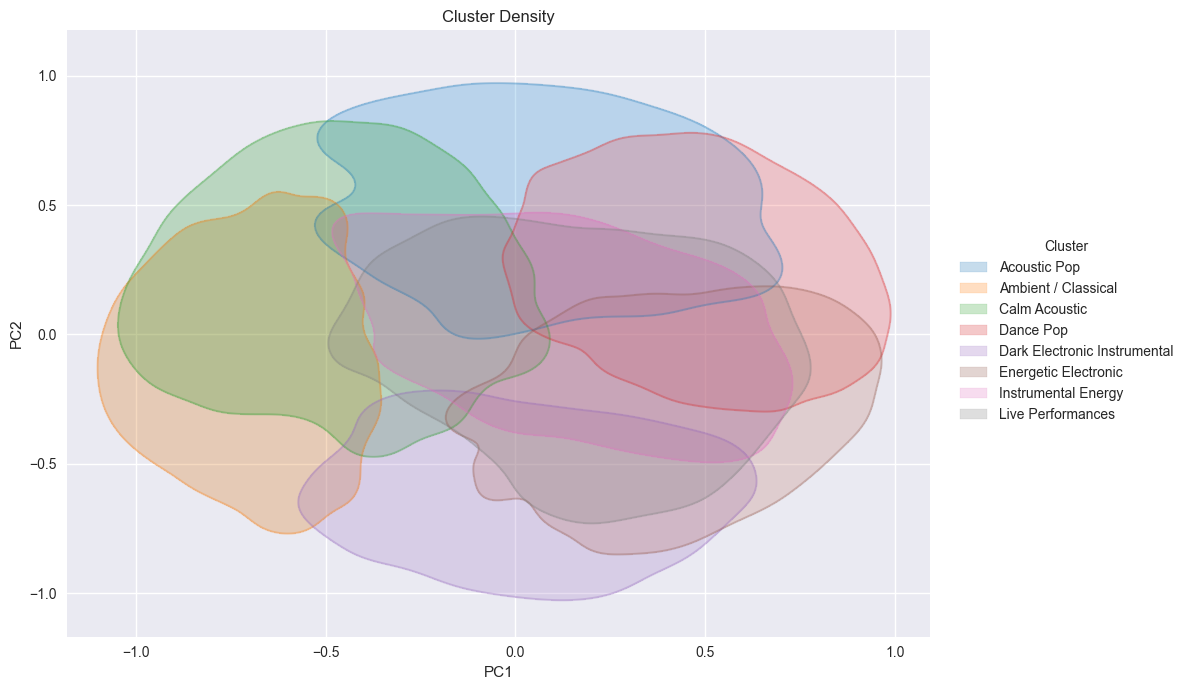

In [32]:
plt.figure(figsize=(12,7))

sample_df = df_model.sample(10000, random_state=42)

cluster_order = sorted(sample_df["cluster_name"].unique())

palette = dict(zip(cluster_order, sns.color_palette("tab10", n_colors=len(cluster_order))))

# Area
sns.kdeplot(
    data=sample_df,
    x="PC1",
    y="PC2",
    hue="cluster_name",
    hue_order=cluster_order,
    palette=palette,
    fill=True,
    alpha=0.25,
    levels=2,
    legend=False
)

# Contours
sns.kdeplot(
    data=sample_df,
    x="PC1",
    y="PC2",
    hue="cluster_name",
    hue_order=cluster_order,
    palette=palette,
    fill=False,
    alpha=0.3,
    levels=1,
    linewidths=1.5,
    legend=False
)

legend_handles = [
    Patch(facecolor=palette[name], edgecolor=palette[name], alpha=0.25, label=name)
    for name in cluster_order
]

plt.legend(
    handles=legend_handles,
    title="Cluster",
    bbox_to_anchor=(1.02, 0.675),
    loc="upper left"
)

plt.title("Cluster Density")
plt.tight_layout()
# plt.savefig("cluster_plot.png", dpi=300, bbox_inches="tight")
plt.show()

The PCA visualization reveals how songs are distributed in the feature space and how the clusters occupy distinct regions. 

While 8 clusters were used, some overlap between clusters was observed. \
Reducing the number of clusters lead to slightly more distinct groupings, but also reduced granularity. \
Therefore, 8 clusters were retained to capture more detailed structure in the data.

Overall, the chosen audio features are efficient in describing the songs because clusters can be defined and characterized by the features themselves.

## Limitations

This recommendation system is based solely on audio features and does not incorporate:

- user listening history
- collaborative filtering
- genre or artist similarity

Therefore, recommendations are purely based on musical characteristics rather than user preferences.

## Future Improvements

Possible extensions include:

- hybrid recommender systems
- incorporating genre information, building off of clustering 